#📌 Extracão

In [ ]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

# Fazendo a requisição à API (GitHub)
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    # Convertendo para DataFrame
    df = pd.DataFrame(data)
    print("Dados importados com sucesso!")
else:
    print(f"Erro ao acessar a API: {response.status_code}")

Dados importados com sucesso!


#🔧 Transformação

In [ ]:
# Exemplo de como tratar o aninhamento e a conversão de tipos
df_flat = pd.json_normalize(data) # Achata a estrutura do JSON

# Convertendo a coluna Total para numérico, tratando erros como NaN
df_flat['account.Charges.Total'] = pd.to_numeric(df_flat['account.Charges.Total'], errors='coerce')

# Verificando se restaram valores nulos após a conversão
print(df_flat.isnull().sum())

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [ ]:
# 1. Garantir que a coluna de cobrança mensal seja numérica (float)
df_flat['account.Charges.Monthly'] = pd.to_numeric(df_flat['account.Charges.Monthly'], errors='coerce')

# 2. Criar a coluna Contas_Diarias
# Dividimos o valor mensal por 30 (dias padrão) e arredondamos para 2 casas decimais
df_flat['Contas_Diarias'] = (df_flat['account.Charges.Monthly'] / 30).round(2)

# 3. Visualizar as primeiras linhas para validar a nova métrica
print(df_flat[['customerID', 'account.Charges.Monthly', 'Contas_Diarias']].head())

# Opcional: Verificar se o cálculo gerou algum valor nulo inesperado
print(f"\nValores nulos em Contas_Diarias: {df_flat['Contas_Diarias'].isnull().sum()}")

   customerID  account.Charges.Monthly  Contas_Diarias
0  0002-ORFBO                     65.6            2.19
1  0003-MKNFE                     59.9            2.00
2  0004-TLHLJ                     73.9            2.46
3  0011-IGKFF                     98.0            3.27
4  0013-EXCHZ                     83.9            2.80

Valores nulos em Contas_Diarias: 0


In [ ]:
# 1. Dicionário de tradução para as colunas principais
traduçao_colunas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Parceiro',
    'customer.Dependents': 'Dependentes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Serviço_Telefonico',
    'internet.InternetService': 'Tipo_Internet',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Fatura_Digital',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Valor_Mensal',
    'account.Charges.Total': 'Valor_Total',
    'Contas_Diarias': 'Custo_Diario'
}

# Renomeando as colunas
df_telecom = df_flat.rename(columns=traduçao_colunas)

# 2. Transformação Binária (Mapeamento)
# Convertendo 'Yes'/'No' para 1/0 para facilitar cálculos de taxa de evasão
mapa_binario = {'Yes': 1, 'No': 0, 'Female': 'Feminino', 'Male': 'Masculino'}

colunas_para_mapear = ['Evasao', 'Parceiro', 'Dependentes', 'Serviço_Telefonico', 'Fatura_Digital']

for col in colunas_para_mapear:
    if col in df_telecom.columns:
        df_telecom[col] = df_telecom[col].map({'Yes': 1, 'No': 0})

# Ajustando o gênero para português
df_telecom['Genero'] = df_telecom['Genero'].map({'Female': 'Feminino', 'Male': 'Masculino'})

# 3. Visualizando o resultado final da padronização
print("Colunas traduzidas e dados padronizados:")
print(df_telecom[['ID_Cliente', 'Genero', 'Evasao', 'Custo_Diario']].head())

Colunas traduzidas e dados padronizados:
   ID_Cliente     Genero  Evasao  Custo_Diario
0  0002-ORFBO   Feminino     0.0          2.19
1  0003-MKNFE  Masculino     0.0          2.00
2  0004-TLHLJ  Masculino     1.0          2.46
3  0011-IGKFF  Masculino     1.0          3.27
4  0013-EXCHZ   Feminino     1.0          2.80


#📊 Carga e análise

In [ ]:
# Selecionando apenas as colunas numéricas de interesse
colunas_numericas = ['Meses_Contrato', 'Valor_Mensal', 'Custo_Diario', 'Valor_Total']

# Gerando a tabela estatística
analise_estatistica = df_telecom[colunas_numericas].describe().T

# Adicionando a Mediana, que não vem no describe padrão
analise_estatistica['median'] = df_telecom[colunas_numericas].median()

# Reorganizando para facilitar a leitura
analise_estatistica = analise_estatistica[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

print("Resumo Estatístico dos Clientes:")
print(analise_estatistica.round(2))

Resumo Estatístico dos Clientes:
                   mean   median      std    min     25%      50%      75%  \
Meses_Contrato    32.35    29.00    24.57   0.00    9.00    29.00    55.00   
Valor_Mensal      64.72    70.30    30.13  18.25   35.42    70.30    89.88   
Custo_Diario       2.16     2.34     1.00   0.61    1.18     2.34     3.00   
Valor_Total     2280.63  1391.00  2268.63  18.80  400.22  1391.00  3785.30   

                    max  
Meses_Contrato    72.00  
Valor_Mensal     118.75  
Custo_Diario       3.96  
Valor_Total     8684.80  


In [ ]:
# Taxa Geral de Evasão (Churn Rate)
taxa_evasao = df_telecom['Evasao'].mean() * 100
print(f"\nTaxa Geral de Evasão: {taxa_evasao:.2f}%")

# Verificando a distribuição de Idosos na base
print("\nDistribuição de Idosos (0=Não, 1=Sim):")
print(df_telecom['Idoso'].value_counts(normalize=True).round(2) * 100)


Taxa Geral de Evasão: 26.54%

Distribuição de Idosos (0=Não, 1=Sim):
Idoso
0    84.0
1    16.0
Name: proportion, dtype: float64


/tmp/ipykernel_190/2446393406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Evasao', data=df_telecom, palette='viridis')


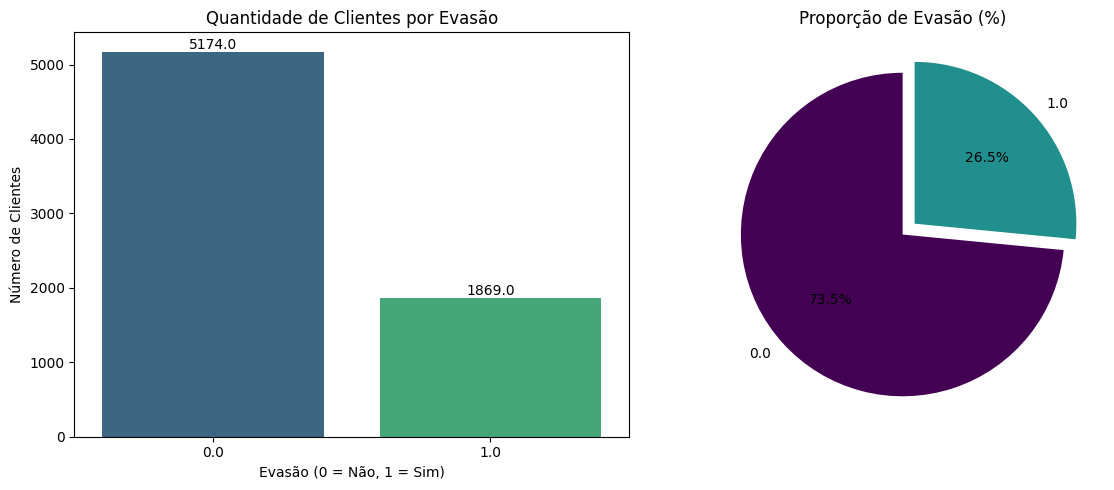

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a área de plotagem
plt.figure(figsize=(12, 5))

# 1. Gráfico de Barras (Frequência)
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Evasao', data=df_telecom, palette='viridis')
plt.title('Quantidade de Clientes por Evasão')
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Número de Clientes')

# Adicionando rótulos de dados nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de Pizza (Proporção)
plt.subplot(1, 2, 2)
df_telecom['Evasao'].value_counts().plot.pie(autopct='%.1f%%', startangle=90, colors=['#440154', '#218F8D'], explode=[0, 0.1])
plt.title('Proporção de Evasão (%)')
plt.ylabel('') # Remove o label lateral

plt.tight_layout()
plt.show()

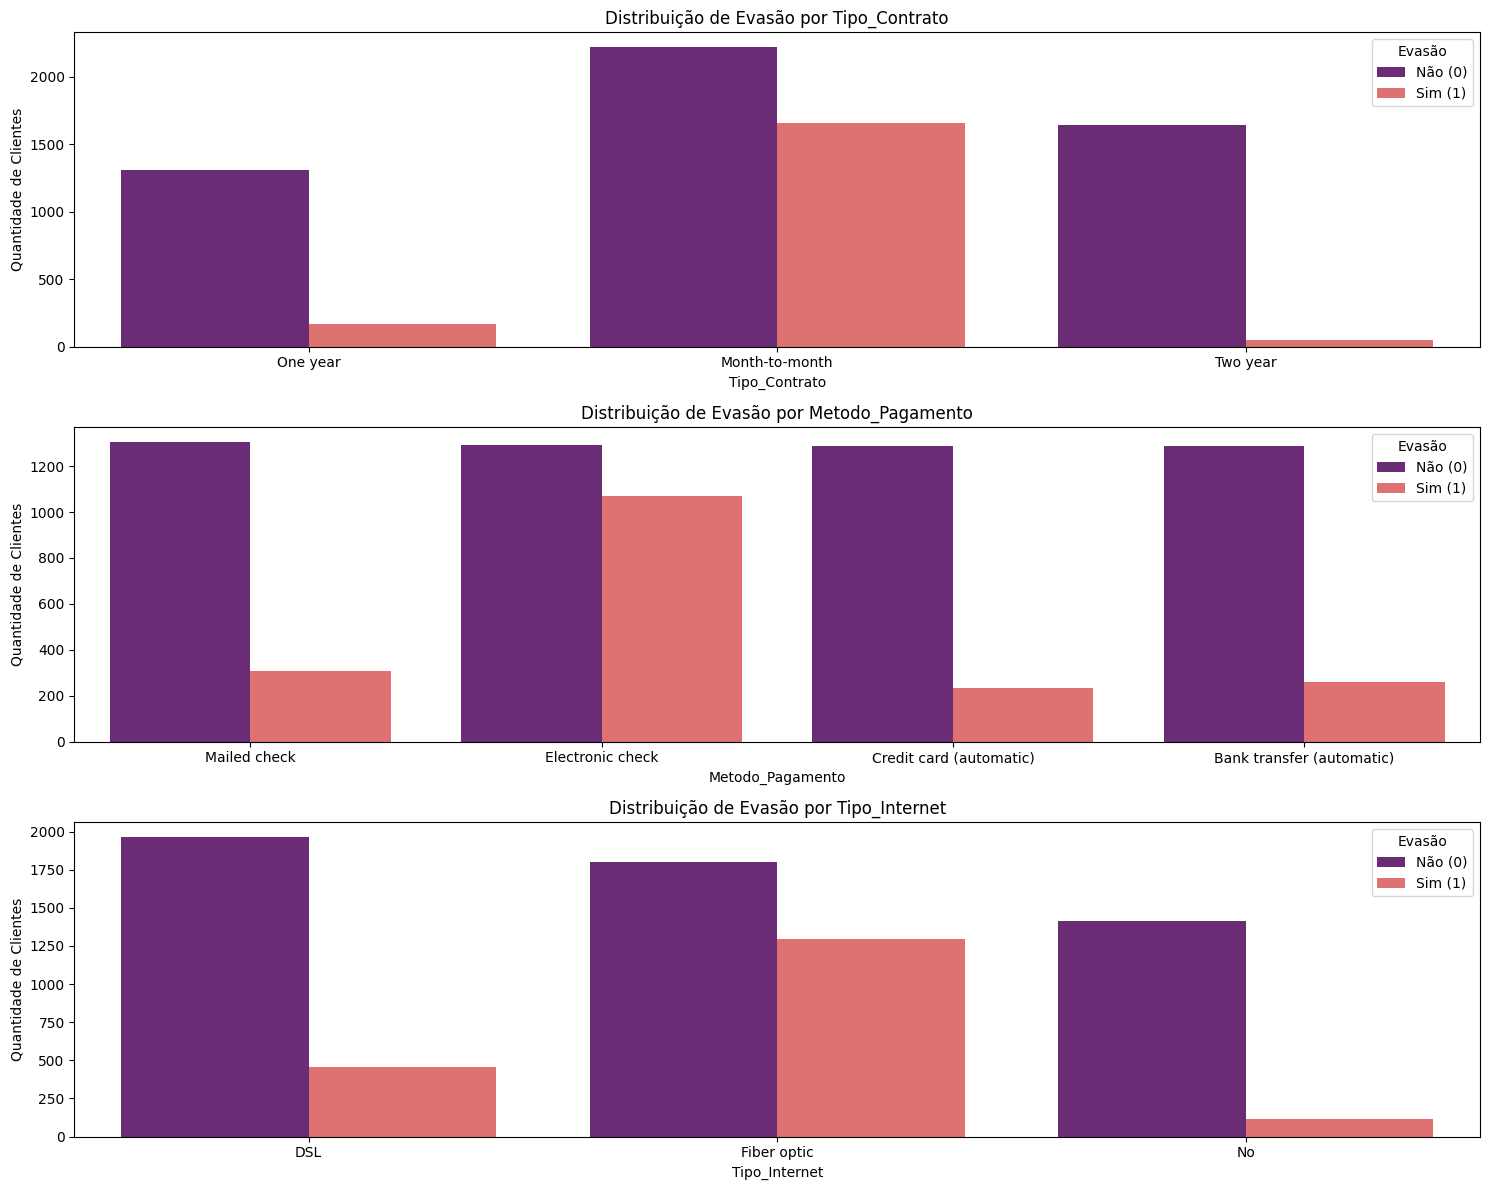

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variáveis para análise
variaveis_cat = ['Tipo_Contrato', 'Metodo_Pagamento', 'Tipo_Internet']

plt.figure(figsize=(15, 12))

for i, col in enumerate(variaveis_cat):
    plt.subplot(3, 1, i+1)

    # Criando um gráfico de contagem com a separação por Evasão
    ax = sns.countplot(x=col, hue='Evasao', data=df_telecom, palette='magma')

    plt.title(f'Distribuição de Evasão por {col}')
    plt.xlabel(col)
    plt.ylabel('Quantidade de Clientes')
    plt.legend(title='Evasão', labels=['Não (0)', 'Sim (1)'])

plt.tight_layout()
plt.show()

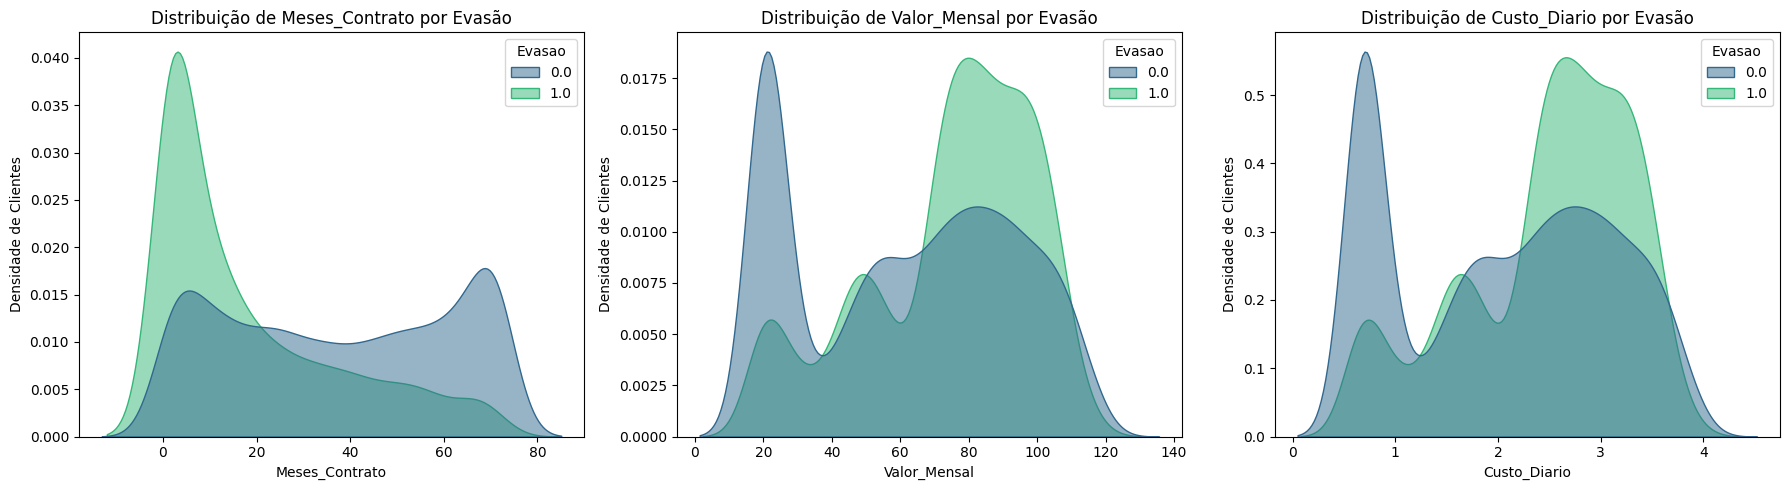

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo as variáveis numéricas para análise
colunas_num = ['Meses_Contrato', 'Valor_Mensal', 'Custo_Diario']

plt.figure(figsize=(18, 5))

for i, col in enumerate(colunas_num):
    plt.subplot(1, 3, i+1)
    # KDE plot mostra a "massa" de clientes ao longo dos valores
    sns.kdeplot(data=df_telecom, x=col, hue='Evasao', fill=True, common_norm=False, palette='viridis', alpha=0.5)
    plt.title(f'Distribuição de {col} por Evasão')
    plt.xlabel(col)
    plt.ylabel('Densidade de Clientes')

plt.tight_layout()
plt.show()

#📄Relatorio Final

1. Introdução
O objetivo deste projeto foi analisar a base de dados de clientes da Telecom X para identificar os principais fatores que levam ao Churn (cancelamento de serviços). A evasão de clientes é um dos maiores desafios do setor de telecomunicações, impactando diretamente a receita e aumentando os custos de aquisição de novos usuários. Esta análise servirá como base para que a equipe de Data Science desenvolva modelos preditivos e para que o time de Customer Success crie estratégias de retenção.

2. Limpeza e Tratamento de Dados (ETL)
Para garantir a confiabilidade das análises, realizamos um processo rigoroso de ETL:

Extração: Os dados foram consumidos diretamente de uma API (GitHub) no formato JSON.

Normalização: Como o JSON era aninhado, utilizamos pd.json_normalize para achatar as colunas de perfil, serviços e conta.

Tipagem: Convertemos colunas financeiras (como Valor_Total) de texto para numérico e tratamos valores ausentes (NaN).

Tradução e Padronização: Renomeamos as colunas para o português e mapeamos variáveis categóricas ("Yes"/"No") para valores binários (1/0), facilitando o processamento estatístico.

Feature Engineering: Criamos a métrica "Custo_Diario", dividindo o faturamento mensal por 30, para entender o peso diário do serviço no bolso do cliente.

3. Análise Exploratória de Dados (EDA)
Durante a exploração, identificamos padrões críticos através de visualizações:

A. Perfil Geral de Evasão
Visualizamos que a taxa de churn da empresa está em torno de 26,5%. Embora a maioria dos clientes permaneça, a perda de 1/4 da base é um sinal de alerta.

B. Impacto do Tipo de Contrato e Pagamento
Contratos: Clientes com contratos "Mês a mês" apresentam uma taxa de evasão drasticamente superior aos de contrato anual ou bianual.

Pagamento: O método de "Cheque Eletrônico" está fortemente correlacionado com o churn, sugerindo fricção no processo de pagamento ou perfil de cliente mais volátil.

C. Comportamento Financeiro e Tempo de Casa
Tenure (Meses de Contrato): A maior concentração de cancelamentos ocorre nos primeiros 6 meses. Clientes que superam a barreira de 1 ano tendem a se tornar fiéis.

Valor Mensal: Clientes que evadem tendem a ter faturas mensais mais altas (acima de R$ 70,00), indicando que o preço é um fator determinante para a saída.

4. Conclusões e Insights
A "Crise dos Primeiros Meses": A Telecom X perde muitos clientes logo no início da jornada. Isso sugere problemas na instalação, expectativa vs. realidade ou onboarding ineficiente.

Sensibilidade ao Preço: Clientes com faturas mais elevadas não percebem valor suficiente para manter o serviço, buscando alternativas mais baratas no mercado.

Fidelização por Contrato: O modelo de contrato mensal é a principal porta de saída. A migração para planos anuais é a forma mais eficaz de retenção.

5. Recomendações Estratégicas
Com base nos dados, sugerimos as seguintes ações para a Telecom X:

Programa de Boas-Vindas: Criar uma régua de comunicação e suporte prioritário para clientes nos primeiros 90 dias (período de maior risco).

Incentivo à Fidelização: Oferecer descontos progressivos ou benefícios exclusivos para clientes que migrarem do plano "Mês a mês" para o "Anual".

Revisão do Pagamento: Investigar falhas no processo de "Cheque Eletrônico" ou oferecer bônus para clientes que cadastrarem o débito automático/cartão de crédito.

Plano de Retenção para High-Ticket: Monitorar clientes com contas diárias acima da média e oferecer upgrades de serviço ou descontos preventivos antes que eles entrem em zona de cancelamento.

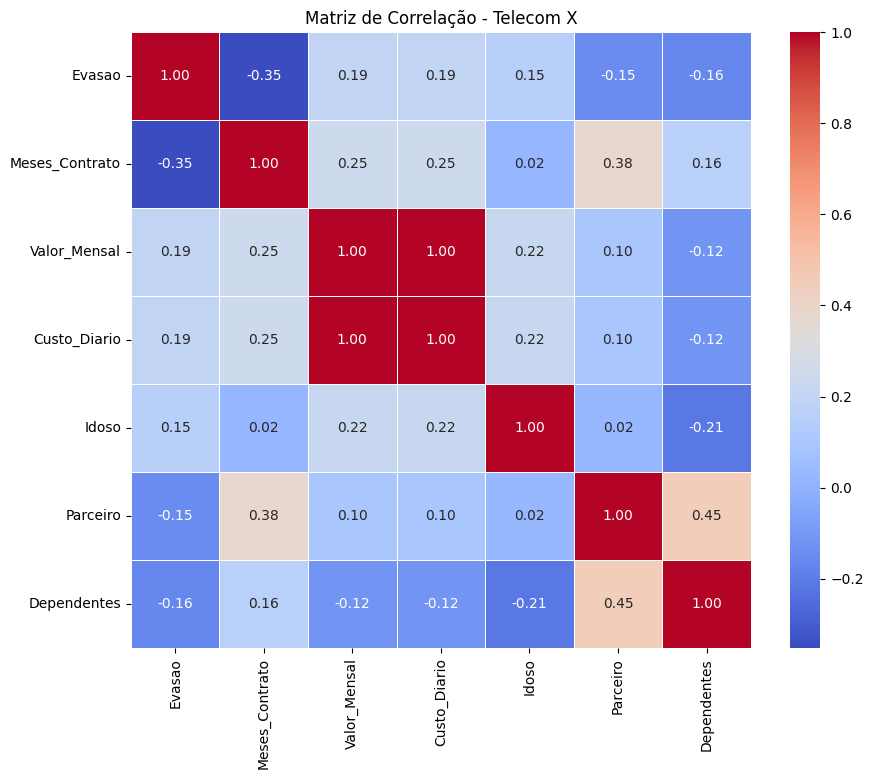

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando colunas numéricas e as que transformamos em binárias
colunas_correlacao = [
    'Evasao', 'Meses_Contrato', 'Valor_Mensal',
    'Custo_Diario', 'Idoso', 'Parceiro', 'Dependentes'
]

# Calculando a matriz de correlação (Pearson)
matriz_corr = df_telecom[colunas_correlacao].corr()

# Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação - Telecom X')
plt.show()

/tmp/ipykernel_190/1172007352.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Servicos', y='Evasao', data=df_telecom, palette='Blues_d')


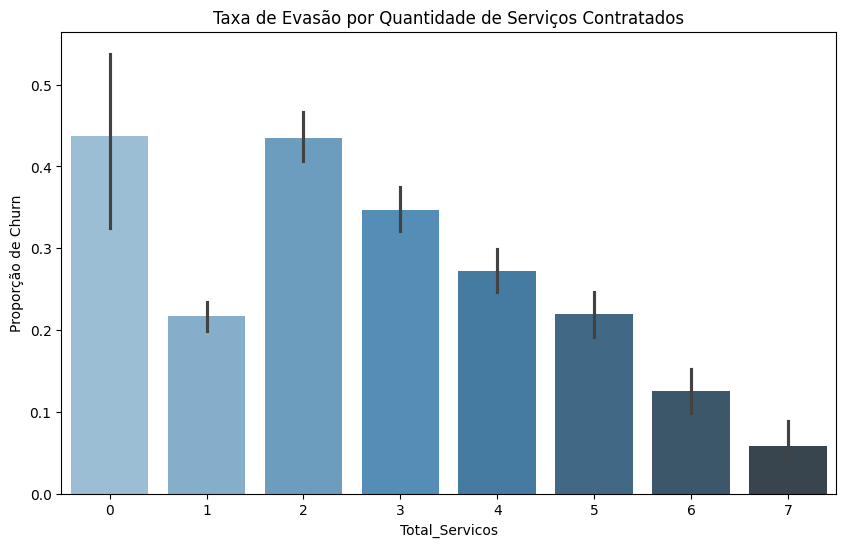

In [ ]:
# Lista de colunas de serviços (precisam estar no formato original ou mapeadas)
servicos = [
    'phone.PhoneService', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
    'internet.StreamingMovies'
]

# Criando a contagem de serviços (Somando onde o valor é 'Yes')
# Nota: use o df original ou ajuste para o mapeamento binário que fizemos
df_telecom['Total_Servicos'] = df_flat[servicos].apply(lambda x: x.str.contains('Yes')).sum(axis=1)

# Visualizando a relação entre Total de Serviços e a Taxa de Evasão
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Servicos', y='Evasao', data=df_telecom, palette='Blues_d')
plt.title('Taxa de Evasão por Quantidade de Serviços Contratados')
plt.ylabel('Proporção de Churn')
plt.show()